In [4]:
%load_ext autoreload 
%autoreload 2
%reload_ext autoreload

import os
import numpy as np
import matplotlib.pyplot as plt


In [49]:
ref_source    = 'GEFSv12'
experiment='EX29'
region_name='CONUS'

In [47]:
def return_data_dir(week_lead, ref_source,region_name):
    return (f'Data/model_npy_input_data/{region_name}/Wk{week_lead}_EX_input_data' if ref_source == 'GEFSv12' else  f'Data/{model_npy_input_data}/{region_name}/Wk{week_lead}_ECMWF_EX_input_data')


In [30]:
def return_channel_names(week_lead, experiment):
    #feature channel names (predictors)
    with open(f"channel_list_information/Wk{week_lead}/{experiment}_RZSM_channel_list.txt") as f:
        names = [line.strip() for line in f]
    names = [s.split()[-1] for s in names]
    print(names)
    return names

In [31]:
def return_precomputed_shap(week_lead, channel_names):
    # --- USER‐DEFINED PARAMETERS ---

    
    Ks            = [10, 25, 50, 100, 250, 500]
    base_dir      = f"Data/shap_tests/Wk{week_lead}"
    channel_names = names   # your list of length C
    C             = len(channel_names)
    
    # --- LOAD RESULTS FROM DISK ---
    mean_abs_dict = {}
    var_dict      = {}
    flat_abs_dict = {}
    
    for K in Ks:
        run_dir = os.path.join(base_dir, f"K{K}_background_gradient_explainer")
        # load per‐channel stats
        mean_abs = np.load(os.path.join(run_dir, "mean_abs.npy"))  # shape (C,)
        var_shap = np.load(os.path.join(run_dir, "var.npy"))       # shape (C,)
        # load full SHAP array and flatten across samples & spatial dims
        shap_values = np.load(os.path.join(run_dir, "shap_values.npy"))  # (N_test, H, W, C)
        flat = shap_values.reshape(-1, C)
        flat_abs_dict[K] = np.abs(flat).flatten()
        
        mean_abs_dict[K] = mean_abs
        var_dict[K]      = var_shap
    return mean_abs_dict, var_dict, flat_abs_dict, Ks, C



Working on lead 1
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'pwat_obs_lag-1', 'spfh_obs_lag-1', 'tmax_obs_lag-1', 'diff_temp_obs_lag-1', 'z200_obs_lag-1', 'pwat_ref_lead1', 'spfh_ref_lead1', 'tmax_ref_lead1', 'diff_temp_ref_lead1', 'z200_ref_lead1']
Working on lead 2
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'pwat_obs_lag-1', 'spfh_obs_lag-1', 'tmax_obs_lag-1', 'diff_temp_obs_lag-1', 'z200_obs_lag-1', 'RZSM_prediction_lead1', 'pwat_ref_lead2', 'spfh_ref_lead2', 'tmax_ref_lead2', 'diff_temp_ref_lead2', 'z200_ref_lead2']
Working on lead 3
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'RZSM_prediction_lead1', 'RZSM_prediction_lead2']
Working on lead 4
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'RZSM_prediction_lead1', 'RZSM_prediction_lead2', 'RZSM_prediction_lead3']


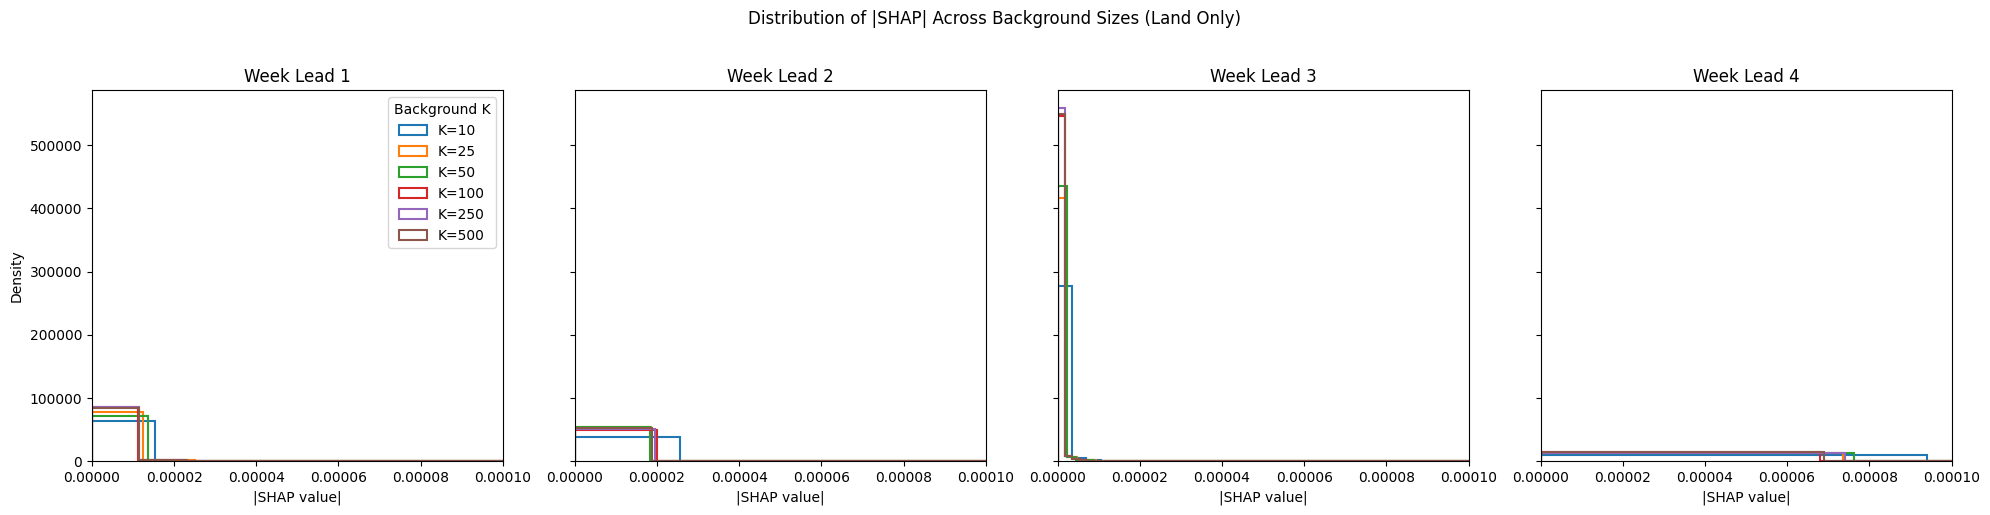

In [51]:
week_leads = [1,2,3,4]
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, week_lead in zip(axes, week_leads):
    print(f"Working on lead {week_lead}")
    # load precomputed SHAP data for this week_lead
    names    = return_channel_names(week_lead, experiment)
    mean_abs_dict, var_dict, flat_abs_dict, Ks, C = return_precomputed_shap(week_lead, channel_names)

    X_test = np.load(f'{return_data_dir(week_lead, ref_source,region_name)}/{experiment}_RZSM_testing_input.npy')
    
    X_flat = X_test[..., :C].reshape(-1, C)   # shape = (n_pixels, C)

    # find which column is the SM channel
    soil_idx = next(i for i,nm in enumerate(names) if "RZSM" in nm)

    for K in Ks:
        # 1) recover the 2-D SHAP array (n_pixels, C)
        sv2d = flat_abs_dict[K].reshape(-1, C)

        # 2) mask out ocean pixels
        mask_ocean = (X_flat[:, soil_idx] == 0)
        sv_land    = sv2d[~mask_ocean, :]       # shape = (n_land_pixels, C)

        # 3) flatten the land-only values for histogram
        land_data = sv_land.flatten()

        ax.hist(
            land_data,
            bins=100,
            density=True,
            histtype='step',
            linewidth=1.5,
            label=f"K={K}"
        )

    # formatting
    ax.set_xlim(0, 0.0001)
    ax.set_xlabel("|SHAP value|")
    ax.set_title(f"Week Lead {week_lead}")
    if week_lead == week_leads[0]:
        ax.set_ylabel("Density")
        ax.legend(title="Background K", loc="upper right")

plt.suptitle("Distribution of |SHAP| Across Background Sizes (Land Only)", y=1.02)
plt.tight_layout()
plt.show()

Working on lead 1
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'pwat_obs_lag-1', 'spfh_obs_lag-1', 'tmax_obs_lag-1', 'diff_temp_obs_lag-1', 'z200_obs_lag-1', 'pwat_ref_lead1', 'spfh_ref_lead1', 'tmax_ref_lead1', 'diff_temp_ref_lead1', 'z200_ref_lead1']
Working on lead 2
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'pwat_obs_lag-1', 'spfh_obs_lag-1', 'tmax_obs_lag-1', 'diff_temp_obs_lag-1', 'z200_obs_lag-1', 'RZSM_prediction_lead1', 'pwat_ref_lead2', 'spfh_ref_lead2', 'tmax_ref_lead2', 'diff_temp_ref_lead2', 'z200_ref_lead2']
Working on lead 3
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'RZSM_prediction_lead1', 'RZSM_prediction_lead2']
Working on lead 4
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'RZSM_prediction_lead1', 'RZSM_prediction_lead2', 'RZSM_prediction_lead3']


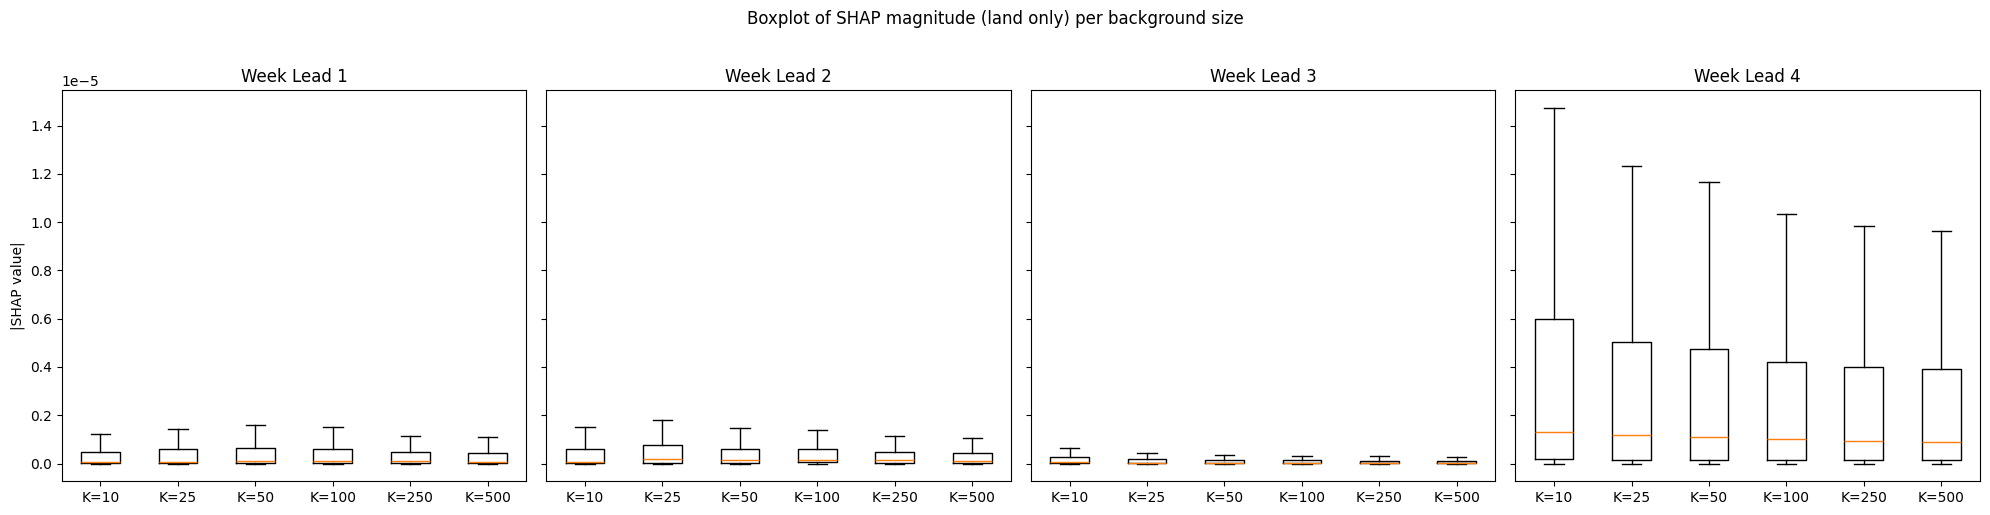

In [52]:
# --- 2) Boxplot of |SHAP| distributions per K ---

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, week_lead in zip(axes, week_leads):
    print(f"Working on lead {week_lead}")
    # load precomputed SHAP data for this week_lead
    
    names    = return_channel_names(week_lead, experiment)
    mean_abs_dict, var_dict, flat_abs_dict, Ks, C = return_precomputed_shap(week_lead, channel_names)

    # 1) figure out which column is your soil‐moisture channel
    X_test = np.load(f'{return_data_dir(week_lead, ref_source,region_name)}/{experiment}_RZSM_testing_input.npy')
    
    X_flat = X_test[..., :C].reshape(-1, C)   # shape = (n_pixels, C)

    # find which column is the SM channel
    soil_idx = next(i for i,nm in enumerate(names) if "RZSM" in nm)
    
    # build a list of land-only |SHAP| arrays for each K
    box_data = []
    for K in Ks:
        # recover 2D SHAP: (n_pixels, C)
        sv2d = flat_abs_dict[K].reshape(-1, C)
        # mask ocean
        mask_ocean = (X_flat[:, soil_idx] == 0)
        sv_land    = sv2d[~mask_ocean, :]    # (n_land_pixels, C)
        # flatten and add to list
        box_data.append(sv_land.flatten())

    # draw the boxplot
    ax.boxplot(
        box_data,
        labels=[f"K={K}" for K in Ks],
        showfliers=False
    )
    if week_lead == week_leads[0]:
        ax.set_ylabel("|SHAP value|")
    ax.set_title(f"Week Lead {week_lead}")

plt.suptitle("Boxplot of SHAP magnitude (land only) per background size", y=1.02)
plt.tight_layout()
plt.show()




Working on lead 1
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'pwat_obs_lag-1', 'spfh_obs_lag-1', 'tmax_obs_lag-1', 'diff_temp_obs_lag-1', 'z200_obs_lag-1', 'pwat_ref_lead1', 'spfh_ref_lead1', 'tmax_ref_lead1', 'diff_temp_ref_lead1', 'z200_ref_lead1']
Working on lead 2
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'pwat_obs_lag-1', 'spfh_obs_lag-1', 'tmax_obs_lag-1', 'diff_temp_obs_lag-1', 'z200_obs_lag-1', 'RZSM_prediction_lead1', 'pwat_ref_lead2', 'spfh_ref_lead2', 'tmax_ref_lead2', 'diff_temp_ref_lead2', 'z200_ref_lead2']
Working on lead 3
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'RZSM_prediction_lead1', 'RZSM_prediction_lead2']
Working on lead 4
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'RZSM_prediction_lead1', 'RZSM_prediction_lead2', 'RZSM_prediction_lead3']


/glade/derecho/scratch/klesinger/tmp/ipykernel_93911/2078644850.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.03,1,0.96])


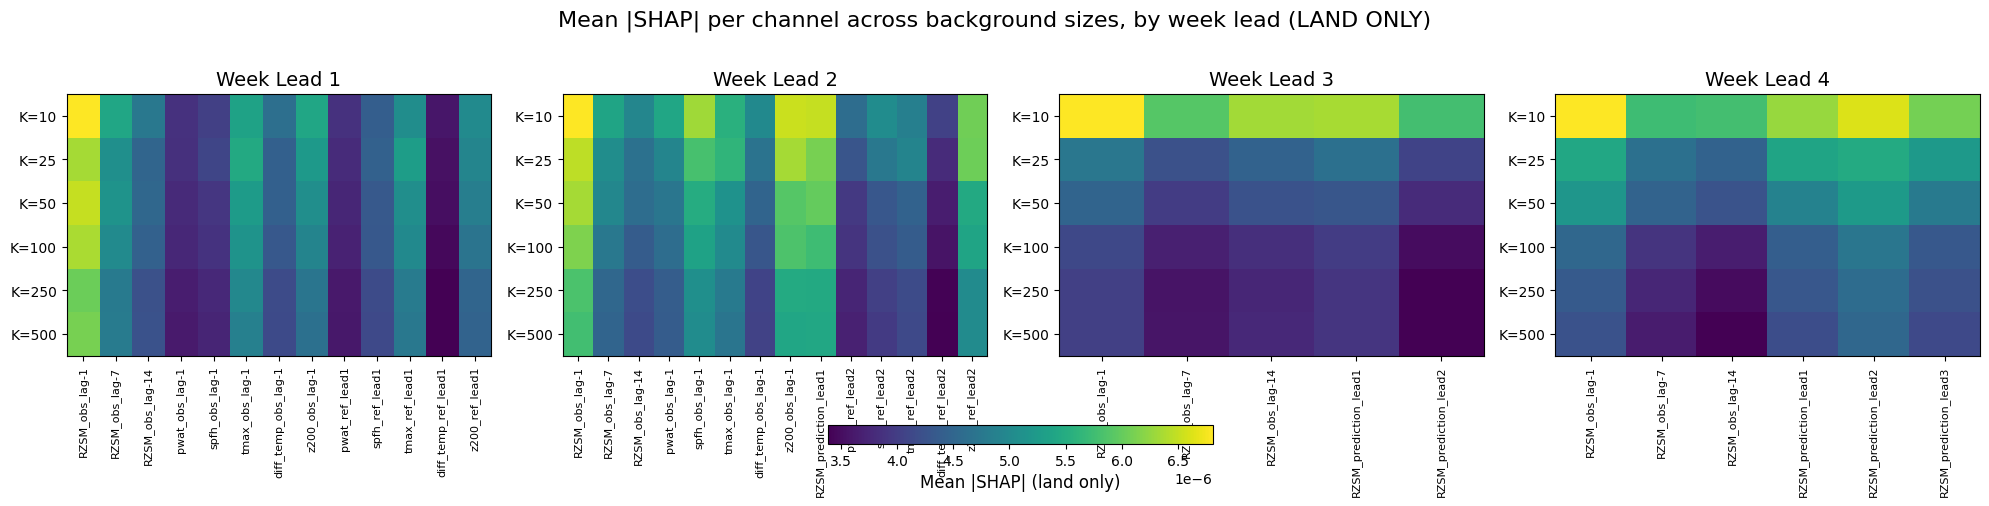

In [58]:
# --- 3) Heatmap of mean(|SHAP|) per channel vs. K ---

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, week_lead in zip(axes, week_leads):
    print(f"Working on lead {week_lead}")
    # load your names and precomputed arrays
    names    = return_channel_names(week_lead, experiment)
    mean_abs_dict, var_dict, flat_abs_dict, Ks, C = return_precomputed_shap(week_lead, channel_names)
    
    C        = len(names)
    # load test data so we can mask ocean
    X_test   = np.load(
        f"{return_data_dir(week_lead, ref_source, region_name)}/"
        f"{experiment}_RZSM_testing_input.npy"
    )  # shape (N_test, H, W, C_max)
    X_flat   = X_test[..., :C].reshape(-1, C)             # (n_pixels, C)
    # find which column is the soil‐moisture channel
    soil_idx = next(i for i,nm in enumerate(names) if "RZSM" in nm)

    # --- 2) Build mean(|SHAP|) matrix, masking ocean pixels ---
    mean_mat = np.zeros((len(Ks), C), dtype=float)
    for j, K in enumerate(Ks):
        # load the full SHAP values for this K
        run_dir     = os.path.join(
            f"Data/shap_tests/Wk{week_lead}", f"K{K}_background_gradient_explainer"  # or however you named it
        )
        shap_values = np.load(os.path.join(run_dir, "shap_values.npy"))
        # reshape to (n_pixels, C)
        sv2d = shap_values.reshape(-1, C)
        # mask ocean
        mask_ocean = (X_flat[:, soil_idx] == 0)
        sv_land    = sv2d[~mask_ocean]
        # compute channel‐wise mean absolute SHAP on land
        mean_mat[j, :] = np.mean(np.abs(sv_land), axis=0)

    # --- 3) Plot heatmap ---
    im = ax.imshow(mean_mat, aspect="auto", interpolation="nearest")
    ax.set_title(f"Week Lead {week_lead}", fontsize=14)
    ax.set_yticks(np.arange(len(Ks)))
    ax.set_yticklabels([f"K={K}" for K in Ks], fontsize=10)
    ax.set_xticks(np.arange(C))
    ax.set_xticklabels(names, rotation=90, fontsize=8)

# 4) Shared colorbar
cbar = fig.colorbar(im, ax=axes.tolist(), orientation="horizontal",
                    fraction=0.05, pad=0.02)
cbar.set_label("Mean |SHAP| (land only)", fontsize=12)

plt.suptitle("Mean |SHAP| per channel across background sizes, by week lead (LAND ONLY)", fontsize=16)
plt.tight_layout(rect=[0,0.03,1,0.96])
plt.show()
# 1.)_ Color intensity = importance

# Brighter (or “hotter”) colors mean that channel had a larger average impact on your model’s scalar output.
# Cooler colors mean the model was relatively insensitive to that channel.

# 2.) Across a row (fixed 𝐾)

# You see a snapshot of how your model “ranks” the channels when you average over that many baselines.

# For 𝐾=10
# K=10, maybe only 3 channels are very bright—those are the few that dominate your SHAP at small baseline sets.

# 3.) Down a column (fixed channel)

# You track how the importance estimate for that channel changes as you increase 𝐾


# If the color for “pwat_eatm” stays roughly the same from K=10 → 𝐾=250
#, you know its importance is robust to your choice of baseline set.

# If instead it starts bright at 𝐾=25
# K=25 and then dims by 𝐾=100
# that channel’s “true” influence is smaller—you were overestimating it at intermediate 𝐾



['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'pwat_obs_lag-1', 'spfh_obs_lag-1', 'tmax_obs_lag-1', 'diff_temp_obs_lag-1', 'z200_obs_lag-1', 'pwat_ref_lead1', 'spfh_ref_lead1', 'tmax_ref_lead1', 'diff_temp_ref_lead1', 'z200_ref_lead1']
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'pwat_obs_lag-1', 'spfh_obs_lag-1', 'tmax_obs_lag-1', 'diff_temp_obs_lag-1', 'z200_obs_lag-1', 'RZSM_prediction_lead1', 'pwat_ref_lead2', 'spfh_ref_lead2', 'tmax_ref_lead2', 'diff_temp_ref_lead2', 'z200_ref_lead2']
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'RZSM_prediction_lead1', 'RZSM_prediction_lead2']
['RZSM_obs_lag-1', 'RZSM_obs_lag-7', 'RZSM_obs_lag-14', 'RZSM_prediction_lead1', 'RZSM_prediction_lead2', 'RZSM_prediction_lead3']


/glade/derecho/scratch/klesinger/tmp/ipykernel_93911/1452696436.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.03,1,0.95])


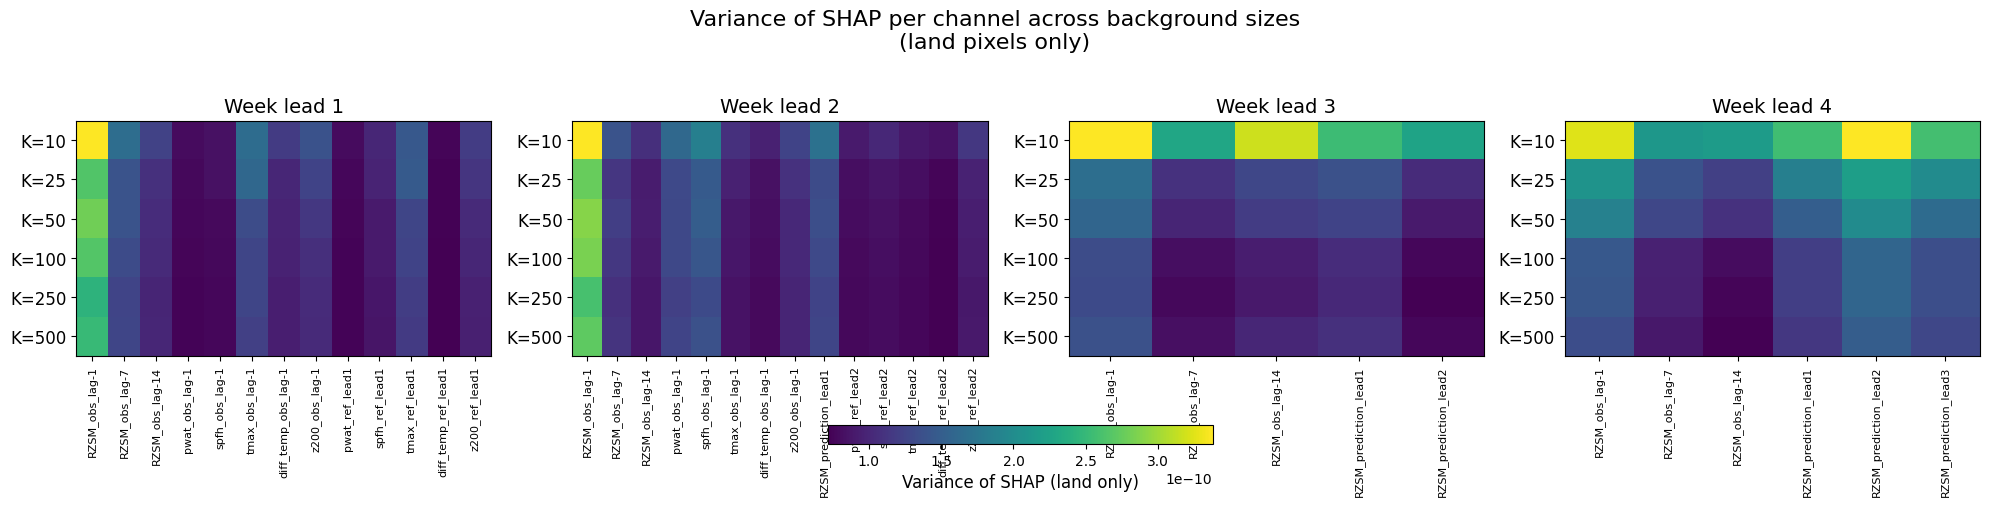

In [59]:

# --- 4) Heatmap of variance(ϕ) per channel vs. K ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=False)

for ax, week_lead in zip(axes, week_leads):
    # --- Load precomputed SHAP data for this week_lead ---
    names    = return_channel_names(week_lead, experiment)
    mean_abs_dict, var_dict, flat_abs_dict, Ks, C = return_precomputed_shap(week_lead, channel_names)
    
    # 2) load X_test and flatten it
    X_test = np.load(
        f"{return_data_dir(week_lead, ref_source, region_name)}/"
        f"{experiment}_RZSM_testing_input.npy"
    )  # shape (N_test, H, W, C_max)
    X_flat = X_test[..., :C].reshape(-1, C)       # shape (n_pixels, C)

    # 3) find the soil‐moisture channel idx
    soil_idx = next(i for i,nm in enumerate(names) if "RZSM" in nm)

    # 4) build a (len(Ks) × C) variance matrix over land pixels
    var_mat = np.zeros((len(Ks), C), dtype=float)
    for j, K in enumerate(Ks):
        # load the full SHAP array for this K
        run_dir     = os.path.join(
            f"Data/shap_tests/Wk{week_lead}", f"K{K}_background_gradient_explainer"  # or however you named it
        )
        shap_values = np.load(os.path.join(run_dir, "shap_values.npy"))  # (N_test,H,W,C)
        sv2d        = shap_values.reshape(-1, C)                         # (n_pixels, C)

        # mask out ocean where soil‐moisture == 0
        mask_ocean = (X_flat[:, soil_idx] == 0)
        sv_land    = sv2d[~mask_ocean, :]  # only land pixels

        # compute per‐channel variance
        var_mat[j, :] = np.var(sv_land, axis=0)

    # 5) plot it
    im = ax.imshow(var_mat, aspect='auto', interpolation='nearest')
    ax.set_title(f"Week lead {week_lead}", fontsize=14)
    ax.set_yticks(np.arange(len(Ks)))
    ax.set_yticklabels([f"K={K}" for K in Ks], fontsize=12)
    ax.set_xticks(np.arange(C))
    ax.set_xticklabels(names, rotation=90, fontsize=8)

# 6) shared colorbar
cbar = fig.colorbar(im, ax=axes.tolist(), orientation='horizontal',
                    fraction=0.05, pad=0.02)
cbar.set_label("Variance of SHAP (land only)", fontsize=12)

plt.suptitle("Variance of SHAP per channel across background sizes\n(land pixels only)", fontsize=16)
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.show()
# The “Variance of SHAP per channel across background sizes” heatmap is telling you, for each feature and each choice of 𝐾 
# how spread-out your SHAP attributions are. Here’s how to read it:

# 1.) What variance means

# For a given channel 𝑖 and background size 𝐾 you collected SHAP values {𝜙𝑖(𝑝)}{ϕ i(p)} over every test pixel and sample.

# The cell’s value is Var({𝜙𝑖(𝑝)})Var({ϕ i(p)}), i.e. how much those attributions wiggle around their mean.

# 2.) Across a row (fixed 𝐾)

# Look at which channels have bright (high‐variance) vs. dark (low‐variance) colors.

# High variance here means that when you explain across all your test points, that feature’s effect
# is very inconsistent—sometimes it drives the prediction way up, other times way down.

# Low variance means it has a stable influence (always a small positive push, say).

# 3.) Down a column (fixed channel)

# You see how the variance estimate for that channel changes as you increase 𝐾.

# If the variance drops from 𝐾=10K=10 → 𝐾 =250
# K=250, it means small baseline sets were giving you noisy, unstable attributions 
# for that feature—and adding more baselines “smooths” that noise out.

# If the variance is already low at K=10 and stays low, that feature’s attribution is inherently stable—you don’t need many backgrounds to estimate it.

